# Bank Customer Churn KDD — Phase 2

## Customer Segmentation via Clustering

This notebook was split from `notebook.ipynb`. The analytical cells are kept in their original order; only reusable setup, prerequisite checks, and project-root-aware paths were added.

In [1]:
# Shared imports and project-root-aware artifact paths
from pathlib import Path
import sys
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.ensemble import IsolationForest
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (
            (candidate / 'src' / '_pipeline_utils.py').is_file()
            and (candidate / 'notebooks' / 'notebook.ipynb').is_file()
        )
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError(
        'Open this notebook from inside the Project_DATAMINING repository.'
    )

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'churn.csv'
CLEAN_PATH = PROCESSED_DIR / 'churn_clean.csv'
CLUSTER_MATRIX = PROCESSED_DIR / 'churn_clustering_matrix.csv'
TRANSACTIONS_PATH = PROCESSED_DIR / 'churn_transactions.csv'
OHE_TRANSACTIONS_PATH = PROCESSED_DIR / 'churn_ohe_transactions.csv'
CLUSTERED_PATH = PROCESSED_DIR / 'churn_clustered.csv'
DBSCAN_OUTLIERS_PATH = PROCESSED_DIR / 'dbscan_outlier_indices.npy'
TOP_RULES_PATH = OUTPUTS_DIR / 'ph3_top_association_rules.csv'
ALL_RULES_PATH = OUTPUTS_DIR / 'ph3_all_association_rules.csv'
ANOMALY_REPORT_PATH = OUTPUTS_DIR / 'ph4_anomaly_report.csv'
HIGH_CONFIDENCE_ANOMALIES_PATH = OUTPUTS_DIR / 'ph4_high_confidence_anomalies.csv'

def require_artifacts(paths, phase_name):
    missing = [path for path in paths if not Path(path).is_file()]
    if missing:
        formatted = '\n'.join(f'  - {path}' for path in missing)
        raise FileNotFoundError(
            f'{phase_name} is missing prerequisite artifacts:\n{formatted}'
        )

print('✔ All libraries loaded successfully.')
print(f'  Project root: {PROJECT_ROOT}')
print(f'  Python:       {sys.version.split()[0]}')
print(f'  Executable:   {sys.executable}')
print(f'  Pandas:       {pd.__version__}')
print(f'  NumPy:        {np.__version__}')


✔ All libraries loaded successfully.
  Project root: C:\Users\Thomas\Documents\Project_DATAMINING
  Python:       3.11.9
  Executable:   C:\Users\Thomas\Documents\Project_DATAMINING\.venv\Scripts\python.exe
  Pandas:       2.2.2
  NumPy:        1.26.4


## Prerequisites

Requires Phase 1's clean dataset and clustering matrix. Produces clustered datasets and DBSCAN outlier indices.

In [2]:
require_artifacts(
    [RAW_PATH, CLEAN_PATH, CLUSTER_MATRIX],
    'Phase 2',
)
df = pd.read_csv(CLEAN_PATH)
_profile_columns = ['Geography', 'Gender', 'Exited']
_matrix_profiles = pd.read_csv(CLUSTER_MATRIX, usecols=_profile_columns)
if len(df) != len(_matrix_profiles):
    raise ValueError('Phase 2 clean data and clustering matrix row counts differ.')
for _column in _profile_columns:
    if not df[_column].reset_index(drop=True).equals(
        _matrix_profiles[_column].reset_index(drop=True)
    ):
        raise ValueError(
            f'Phase 2 row alignment check failed for {_column!r}. Rerun Phase 1.'
        )
print(f'✔ Phase 2 prerequisites loaded: {len(df):,} aligned customers.')


✔ Phase 2 prerequisites loaded: 10,000 aligned customers.


## Phase 2: Customer Segmentation via Clustering

**Algorithms Applied:**
1. **K-Means** — Partition-based; requires K; optimal K determined via Elbow + Silhouette
2. **Hierarchical (Agglomerative)** — Tree-based; compare Single, Complete, Average, Ward linkages
3. **DBSCAN** — Density-based; no K required; detects arbitrary shapes + outliers natively

**Validation Metrics:**
- Elbow Method (Within-Cluster Sum of Squares / Inertia)  
- Silhouette Score (Cohesion vs. Separation per cluster)

**Full-Dataset Rule:** All Phase 2 clustering algorithms, validation scores, hierarchical linkage comparisons, and DBSCAN epsilon estimation use all 10,000 records from `data/raw/churn.csv` via the Path A clustering matrix. No row subsampling is used.

**Deliverable:** Named business profiles for each discovered cluster


-- Phase 2 Clustering Input --


  Distance matrix shape: (10000, 8)
  Distance features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
  Profile-only columns excluded from fit: ['Geography', 'Gender', 'Exited']

Running K-Means for K = 2 to 12...


  K= 2 | Inertia: 54,431 | Silhouette: 0.1639


  K= 3 | Inertia: 49,573 | Silhouette: 0.1500


  K= 4 | Inertia: 45,700 | Silhouette: 0.1355


...

  K= 8 | Inertia: 36,626 | Silhouette: 0.1280


  K= 9 | Inertia: 35,116 | Silhouette: 0.1275


  K=10 | Inertia: 33,818 | Silhouette: 0.1298


  K=11 | Inertia: 32,780 | Silhouette: 0.1334


  K=12 | Inertia: 31,808 | Silhouette: 0.1292


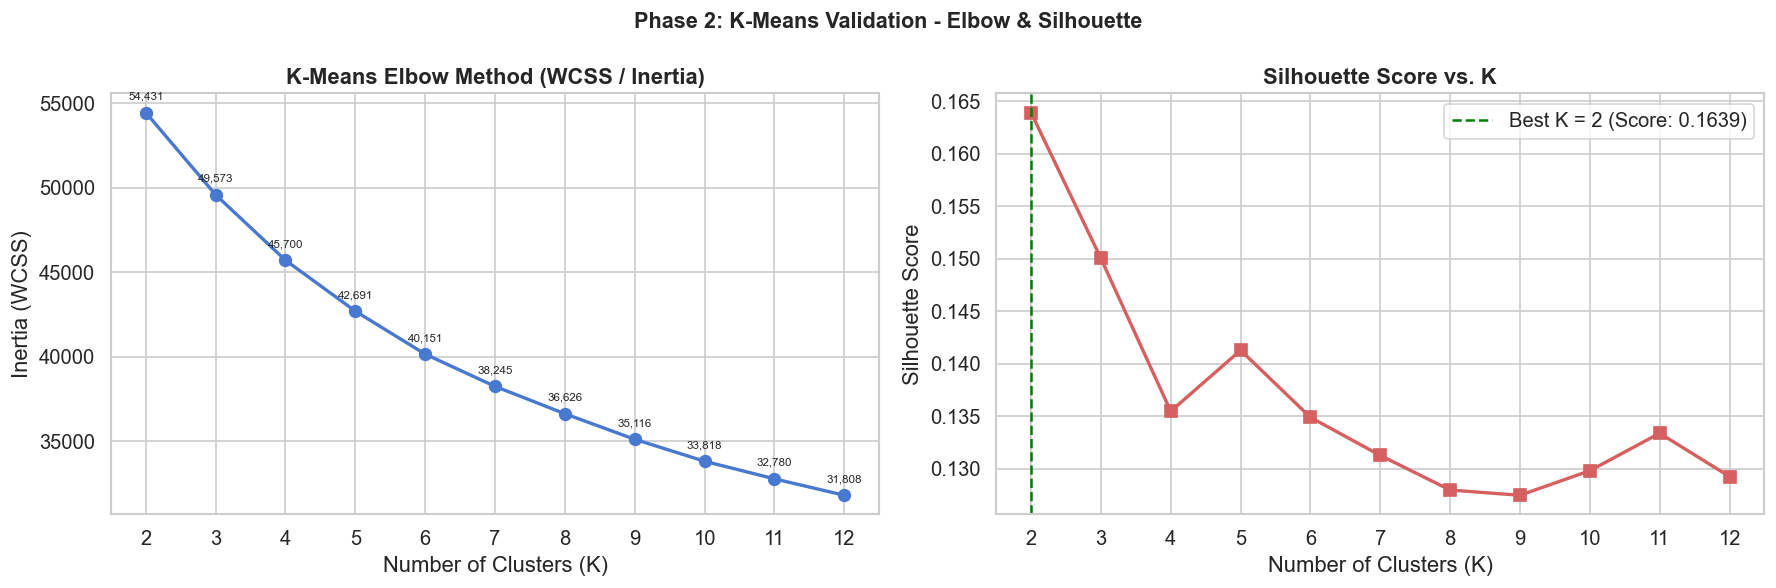


  OK Elbow analysis complete.
  Best Silhouette Score: 0.1639 at K=2


In [3]:
# Load Clustering Matrix
df_cl = pd.read_csv(CLUSTER_MATRIX)

PROFILE_LABEL_COLS = ['Geography', 'Gender', 'Exited']
missing_profile_cols = [col for col in PROFILE_LABEL_COLS if col not in df_cl.columns]
if missing_profile_cols:
    raise ValueError(
        f"Clustering matrix is missing profile-only columns {missing_profile_cols}. "
        "Rerun the Path A preprocessing cell so the old OHE matrix is replaced."
    )

X_cl = df_cl.drop(columns=PROFILE_LABEL_COLS)
y_cl = df_cl['Exited']

raw_row_count = len(pd.read_csv(RAW_PATH, usecols=[0]))
if len(X_cl) != raw_row_count:
    raise ValueError(
        f"Clustering matrix has {len(X_cl):,} rows, but raw data has "
        f"{raw_row_count:,} rows. Phase 2 must use the full dataset."
    )

# Safety check: OHE Geography/Gender should not be in distance-based clustering.
ohe_leak_cols = [col for col in X_cl.columns
                 if col.startswith(('Geography_', 'Gender_'))]
if ohe_leak_cols:
    raise ValueError(
        f"OHE category columns are still present in X_cl: {ohe_leak_cols}. "
        "Rerun Path A after the updated preprocessing change."
    )

print("-- Phase 2 Clustering Input --")
print(f"  Distance matrix shape: {X_cl.shape}")
print(f"  Distance features: {list(X_cl.columns)}")
print(f"  Profile-only columns excluded from fit: {PROFILE_LABEL_COLS}")

# Elbow Method
K_RANGE   = range(2, 13)
inertias  = []
sil_scores = []

print("\nRunning K-Means for K = 2 to 12...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    km.fit(X_cl)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cl, km.labels_)
    sil_scores.append(sil)
    print(f"  K={k:2d} | Inertia: {km.inertia_:,.0f} | Silhouette: {sil:.4f}")

# Plot: Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow
axes[0].plot(K_RANGE, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('K-Means Elbow Method (WCSS / Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(K_RANGE))
for k, v in zip(K_RANGE, inertias):
    axes[0].annotate(f'{v:,.0f}', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=7)

# Silhouette
axes[1].plot(K_RANGE, sil_scores, 'rs-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs. K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))
best_k = list(K_RANGE)[sil_scores.index(max(sil_scores))]
axes[1].axvline(best_k, color='green', linestyle='--', linewidth=1.5,
                label=f'Best K = {best_k} (Score: {max(sil_scores):.4f})')
axes[1].legend()

plt.suptitle('Phase 2: K-Means Validation - Elbow & Silhouette',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()

print(f"\n  OK Elbow analysis complete.")
print(f"  Best Silhouette Score: {max(sil_scores):.4f} at K={best_k}")


### Interpretation — Elbow and Silhouette Disagree, and the Disagreement Is Informative

The two required validity criteria point at different K:

- **Silhouette peaks at K=2 (0.1639).** Refitting K=2 for inspection shows what that partition is: one cluster with 86% zero-balance accounts (n≈4,200) versus one positive-balance cluster (mean ≈ £123K, n≈5,800) — i.e., the bimodal Balance column restated. Geometrically "best", informationally almost tautological.
- **The elbow has no sharp knee**: inertia falls 54.4K → 49.6K → 45.7K → 42.7K with smoothly shrinking increments (−4.9K, −3.9K, −3.0K). Diminishing returns set in around K = 3–5 rather than at one obvious break.
- **The absolute level matters more than the argmax:** silhouettes of 0.13–0.16 *at every K* say this data contains no well-separated spherical islands — consistent with the near-orthogonal correlation structure from Phase 1. Customers form a continuum; any K partitions it into *operational segments*, not natural species.

**Decision: K=3** — inside the elbow's diminishing-returns zone, within 0.014 of the silhouette peak, and one level finer than the trivial balance split. That one extra level is exactly where product depth enters (the profile below separates a multi-product from a single-product high-balance segment), which is what makes the segmentation actionable. K=4–5 split fragments without adding interpretable structure (K=5's local silhouette bump, 0.1413, still trails K=3 and yields two near-duplicate high-balance segments).


  K=3: Silhouette = 0.1500 | Inertia = 49,573
    Saved → C:\Users\Thomas\Documents\Project_DATAMINING\data\processed\churn_clustered_K3.csv


  K=4: Silhouette = 0.1355 | Inertia = 45,700
    Saved → C:\Users\Thomas\Documents\Project_DATAMINING\data\processed\churn_clustered_K4.csv


  K=5: Silhouette = 0.1413 | Inertia = 42,691
    Saved → C:\Users\Thomas\Documents\Project_DATAMINING\data\processed\churn_clustered_K5.csv


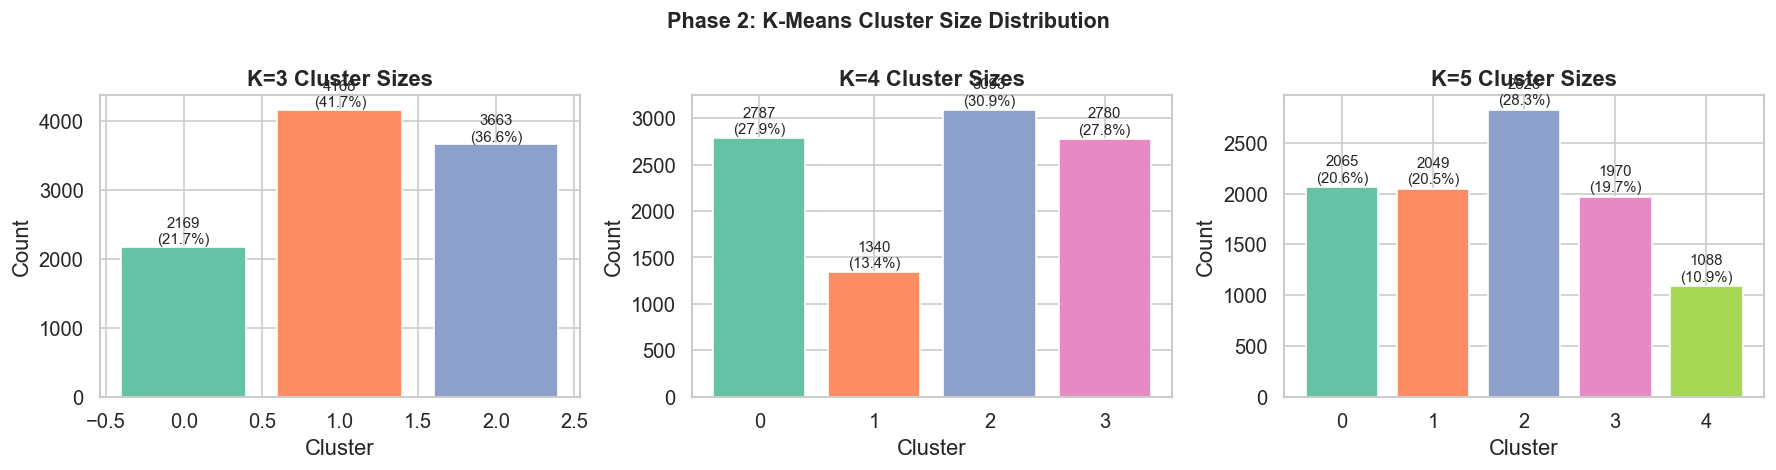

In [4]:
# ── Train Final K-Means Models ────────────────────────────────────────────────
CANDIDATE_K = [3, 4, 5]
km_models   = {}

for k in CANDIDATE_K:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=500)
    km.fit(X_cl)
    km_models[k] = km
    
    label_col = f'KMeans_K{k}'
    df_cl[label_col] = km.labels_
    sil = silhouette_score(X_cl, km.labels_)
    print(f"  K={k}: Silhouette = {sil:.4f} | Inertia = {km.inertia_:,.0f}")
    
    # Save individual clustered datasets
    save_path = PROCESSED_DIR / f'churn_clustered_K{k}.csv'
    df_cl.to_csv(save_path, index=False)
    print(f"    Saved → {save_path}")

# ── Cluster Size Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, k in enumerate(CANDIDATE_K):
    sizes = df_cl[f'KMeans_K{k}'].value_counts().sort_index()
    axes[i].bar(sizes.index, sizes.values, color=sns.color_palette('Set2', k))
    axes[i].set_title(f'K={k} Cluster Sizes', fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Count')
    for j, (idx, val) in enumerate(zip(sizes.index, sizes.values)):
        axes[i].text(idx, val+50, f'{val}\n({val/len(df_cl)*100:.1f}%)',
                     ha='center', fontsize=9)

plt.suptitle('Phase 2: K-Means Cluster Size Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()


In [5]:
# Select Optimal K for Profiling (adjust based on validation results)
# Silhouette may peak at K=2, but K=3 can still be selected for discovery if it
# gives more interpretable financial/behavioral personas. Geography, Gender,
# and Exited are used only after labels are assigned.
OPTIMAL_K = 3

df_original = df.copy()
df_original['Cluster'] = km_models[OPTIMAL_K].labels_

# Cluster Profile Table
profile_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                'HasCrCard', 'EstimatedSalary', 'IsActiveMember', 'Exited']
profile = df_original.groupby('Cluster')[profile_cols].mean().round(2)
profile['Count'] = df_original['Cluster'].value_counts().sort_index()
profile['Churn_Rate_%'] = (profile['Exited'] * 100).round(1)
profile['Active_Rate_%'] = (profile['IsActiveMember'] * 100).round(1)
profile['CrCard_Rate_%'] = (profile['HasCrCard'] * 100).round(1)

print(f"-- K={OPTIMAL_K} Cluster Profile Table --")
display(profile.T)

# Category Profiles After Clustering
# OHE is used here only for interpretation: the mean of a 0/1 category column is
# the percentage of the cluster in that category. These columns were not used in
# K-Means, DBSCAN, or Hierarchical distance calculations.
cat_ohe_profile = (
    pd.get_dummies(df_original[['Geography', 'Gender']], dtype=int)
      .join(df_original['Cluster'])
      .groupby('Cluster')
      .mean()
      .mul(100)
      .round(1)
)
print("\n-- Post-Cluster Category Profile (OHE %, not clustering input) --")
display(cat_ohe_profile)

geo_dist = (df_original.groupby(['Cluster','Geography'])
                         .size()
                         .unstack(fill_value=0)
                         .apply(lambda x: x / x.sum() * 100, axis=1)
                         .round(1))
gender_dist = (df_original.groupby(['Cluster','Gender'])
                            .size()
                            .unstack(fill_value=0)
                            .apply(lambda x: x / x.sum() * 100, axis=1)
                            .round(1))
print("\n-- Geography Composition per Cluster (%) --")
display(geo_dist)
print("\n-- Gender Composition per Cluster (%) --")
display(gender_dist)

# Business Profile Naming
# Names are generated from the post-cluster profile so they stay honest after
# the distance matrix changes. Naming tokens are restricted to dimensions the
# separation tests (Deep-Dive 1 below) show actually distinguish the clusters:
# Balance, product depth, and geography composition — plus the churn-risk label
# used as a validation lens. Activity/tenure/credit tokens are deliberately
# omitted: those features do not separate the K=3 clusters (Cramér's V < 0.06).
baseline_churn   = df_original['Exited'].mean() * 100
overall_balance  = df_original['Balance'].mean()
overall_products = df_original['NumOfProducts'].mean()

CLUSTER_NAMES = {}
for k in sorted(profile.index):
    sub_k        = df_original[df_original['Cluster'] == k]
    zero_share   = (sub_k['Balance'] == 0).mean()
    single_share = (sub_k['NumOfProducts'] == 1).mean()

    if zero_share >= 0.90:
        balance_label = 'Zero-Balance'
    elif profile.loc[k, 'Balance'] >= overall_balance:
        balance_label = 'High-Balance'
    else:
        balance_label = 'Low-Balance'

    if single_share >= 0.95:
        product_label = 'Single-Product'
    elif profile.loc[k, 'NumOfProducts'] >= overall_products:
        product_label = 'Multi-Product'
    else:
        product_label = 'Low-Product-Depth'

    dominant_geo = geo_dist.loc[k].idxmax()
    geo_label = f'{dominant_geo}-Skew'
    churn_rate = profile.loc[k, 'Churn_Rate_%']
    if churn_rate >= baseline_churn + 3:
        risk_label = 'Watchlist'
    elif churn_rate <= baseline_churn - 3:
        risk_label = 'Loyalist'
    else:
        risk_label = 'Mixed-Risk'
    CLUSTER_NAMES[k] = f"{balance_label} {product_label} {geo_label} {risk_label}"

df_original['Cluster_Name'] = df_original['Cluster'].map(CLUSTER_NAMES)
print("\n-- CLUSTER PROFILE NAMING --")
for k, name in CLUSTER_NAMES.items():
    count = (df_original['Cluster'] == k).sum()
    churn = df_original[df_original['Cluster'] == k]['Exited'].mean() * 100
    print(f"  Cluster {k}: '{name}'")
    print(f"    Count: {count:,} | Churn Rate: {churn:.1f}%\n")

# Save consolidated clustered dataset
# Includes original Geography/Gender for dashboarding and report profiles.
df_original.to_csv(CLUSTERED_PATH, index=False)
print(f"  OK Final clustered dataset saved to: {CLUSTERED_PATH}")


-- K=3 Cluster Profile Table --


Cluster,0,1,2
CreditScore,652.49,650.38,649.53
Age,38.83,39.46,38.37
Tenure,4.99,4.98,5.07
Balance,120522.34,120139.11,738.77
NumOfProducts,2.13,1.00,1.78
HasCrCard,0.70,0.70,0.72
EstimatedSalary,103192.89,99710.18,98685.50
IsActiveMember,0.52,0.51,0.52
Exited,0.22,0.26,0.14
Count,2169.00,4168.00,3663.00



-- Post-Cluster Category Profile (OHE %, not clustering input) --


,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
Cluster,,,,,
0,31.7,52.4,15.9,46.6,53.4
1,45.6,32.3,22.1,44.5,55.5
2,66.2,0.7,33.1,45.8,54.2



-- Geography Composition per Cluster (%) --


Geography,France,Germany,Spain
Cluster,,,
0,31.7,52.4,15.9
1,45.6,32.3,22.1
2,66.2,0.7,33.1



-- Gender Composition per Cluster (%) --


Gender,Female,Male
Cluster,,
0,46.6,53.4
1,44.5,55.5
2,45.8,54.2



-- CLUSTER PROFILE NAMING --
  Cluster 0: 'High-Balance Multi-Product Germany-Skew Mixed-Risk'
    Count: 2,169 | Churn Rate: 21.8%

  Cluster 1: 'High-Balance Single-Product France-Skew Watchlist'
    Count: 4,168 | Churn Rate: 25.6%

  Cluster 2: 'Zero-Balance Multi-Product France-Skew Loyalist'
    Count: 3,663 | Churn Rate: 13.6%

  OK Final clustered dataset saved to: C:\Users\Thomas\Documents\Project_DATAMINING\data\processed\churn_clustered.csv


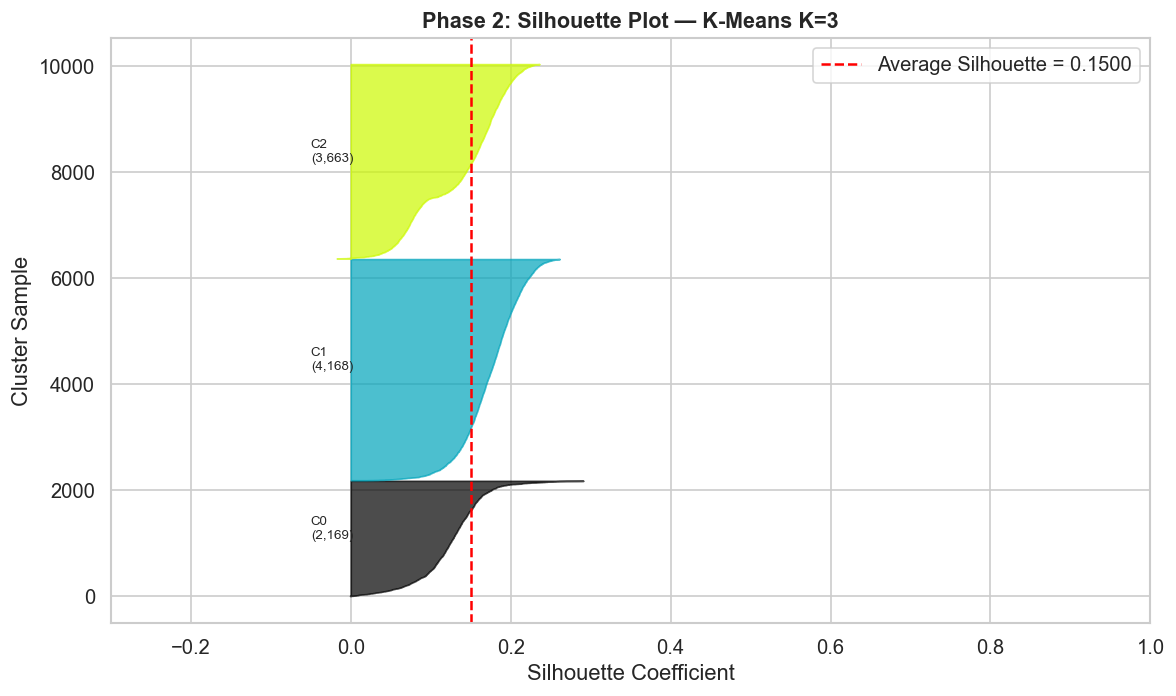

  Average Silhouette Score: 0.1500
  Interpretation:
   > 0.50 → Strong cluster structure
   0.25–0.50 → Moderate structure
   < 0.25 → Weak structure (reconsider K)


In [6]:
# ── Per-Sample Silhouette Analysis ────────────────────────────────────────────
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 6))
sample_sils = silhouette_samples(X_cl, km_models[OPTIMAL_K].labels_)
y_lower = 10

for k in range(OPTIMAL_K):
    cluster_sils = np.sort(sample_sils[km_models[OPTIMAL_K].labels_ == k])
    y_upper = y_lower + len(cluster_sils)
    
    color = cm.nipy_spectral(float(k) / OPTIMAL_K)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sils,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_sils), 
            f'C{k}\n({len(cluster_sils):,})', fontsize=8)
    y_lower = y_upper + 10

avg_sil = silhouette_score(X_cl, km_models[OPTIMAL_K].labels_)
ax.axvline(avg_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Average Silhouette = {avg_sil:.4f}')
ax.set_title(f'Phase 2: Silhouette Plot — K-Means K={OPTIMAL_K}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster Sample')
ax.set_xlim(-0.3, 1.0)
ax.legend()
plt.tight_layout()

plt.show()

print(f"  Average Silhouette Score: {avg_sil:.4f}")
print("  Interpretation:")
print("   > 0.50 → Strong cluster structure")
print("   0.25–0.50 → Moderate structure")
print("   < 0.25 → Weak structure (reconsider K)")


### Interpretation — The Silhouette Verdict for K=3

Applying the printed scale to our own result: **0.150 < 0.25 → weak structure.** The honest reading is that these are *descriptive segments of a continuum*, not sharply separated populations. Three specifics from the per-sample plot:

- **Almost nothing is misassigned.** Only 0.1% of samples have negative silhouette values; the weakness is *shallow separation* (most scores between 0 and 0.3), not wrong membership.
- **Per-cluster cohesion (computed from the same silhouette samples):** C1 — the single-product, high-balance segment — is the most coherent blade (mean 0.174); C0 — multi-product, Germany-skew — the least (0.125); C2 sits between (0.137). C0 and C1 share the high-balance region and differ mainly on product count, so theirs is the soft boundary.
- **Why we proceed with a weak-geometry solution:** the partition is method-stable (Ward reproduces it at ARI = 0.75 below), it is built on features the separation tests confirm differ with *large* effect sizes (Balance ε² = 0.73, NumOfProducts ε² = 0.71), and it is externally meaningful — churn spans 13.6% → 25.6% across clusters, a spread silhouette knows nothing about.

**Conclusion:** silhouette measures geometry, not usefulness. We report the weak geometry and justify the segmentation by stability + effect sizes + business validity, rather than overstating compactness.


### Deep Cluster Exploration — What Are These K=3 Clusters, Concretely?

The profile table above reports cluster means, but means alone do not explain *what a cluster is*. This section answers that in three steps:

1. **Standardized deviation profile** — how far each cluster's mean sits from the population mean, in population-SD units, so all features are comparable on one scale.
2. **Formal separation tests** — Kruskal–Wallis (with ε² effect size) for continuous features and chi-square (with Cramér's V) for categorical ones. At n=10,000 nearly everything is "significant", so clusters are described **only** through features with a non-trivial effect size.
3. **Auto-generated cluster narratives** — a detailed, data-derived explanation of each cluster, including which features it does **not** differ on (over-claiming is penalized just like under-explaining).

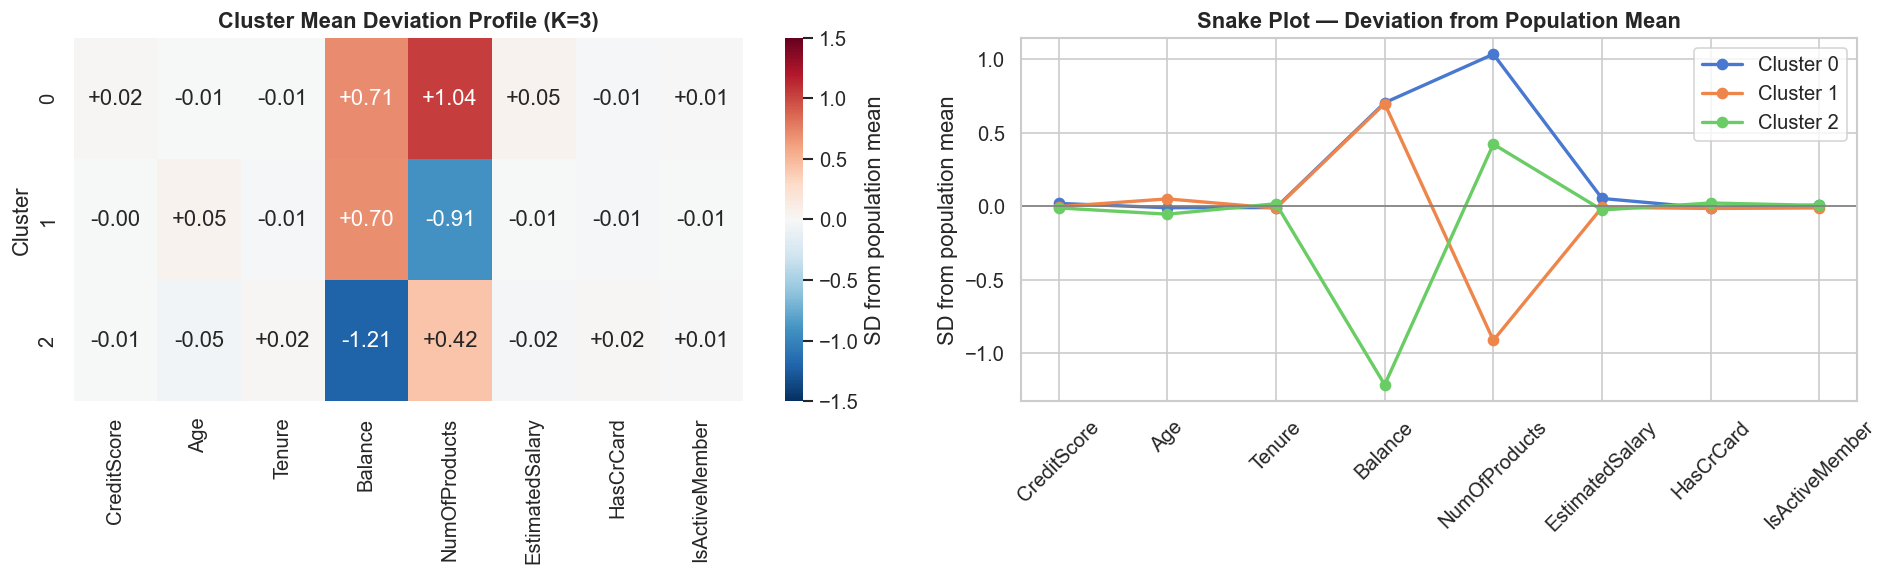

── Cluster Separation Tests (ranked by effect size) ──


,Feature,Test,Stat,p-value,Effect Size,Effect Metric
0,Balance,Kruskal-Wallis,7272.8,0.000000e+00,0.727,epsilon^2
1,NumOfProducts,Kruskal-Wallis,7129.9,0.000000e+00,0.713,epsilon^2
2,NumOfProducts,Chi-square,7471.1,0.000000e+00,0.611,Cramér's V
3,Geography,Chi-square,2139.2,0.000000e+00,0.327,Cramér's V
4,Exited,Chi-square,176.0,5.932661e-39,0.133,Cramér's V
5,HasCrCard,Chi-square,3.1,2.103868e-01,0.018,Cramér's V
6,Gender,Chi-square,2.7,2.627191e-01,0.016,Cramér's V
7,IsActiveMember,Chi-square,0.8,6.703095e-01,0.009,Cramér's V
8,Age,Kruskal-Wallis,26.8,1.530321e-06,0.002,epsilon^2
9,EstimatedSalary,Kruskal-Wallis,8.6,1.330203e-02,0.001,epsilon^2



  Features that DEFINE the clusters (large effect): ['Balance', 'NumOfProducts', 'Geography']
  Features the clusters do NOT meaningfully differ on: ['HasCrCard', 'Gender', 'IsActiveMember', 'Age', 'EstimatedSalary', 'CreditScore', 'Tenure']
  -> Interpretation: the K=3 solution is fundamentally a segmentation on the
     'defining' features. Persona descriptions must be built on those and
     must not over-claim differences on the weak list.


In [7]:
# ── Deep-Dive 1: What Actually Separates the K=3 Clusters? ───────────────────
# (a) Standardized deviation profile: cluster mean vs. population mean, in
#     population-SD units (comparable across features).
# (b) Separation tests: Kruskal-Wallis + epsilon-squared for continuous,
#     chi-square + Cramér's V for categorical. Effect sizes matter more than
#     p-values at n=10,000.

num_feats = ['CreditScore', 'Age', 'Tenure', 'Balance',
             'NumOfProducts', 'EstimatedSalary']
bin_feats = ['HasCrCard', 'IsActiveMember']
cat_feats = ['Geography', 'Gender', 'Exited', 'IsActiveMember',
             'HasCrCard', 'NumOfProducts']

# (a) Standardized deviation profile
pop_mean = df_original[num_feats + bin_feats].mean()
pop_std  = df_original[num_feats + bin_feats].std()
dev_profile = pd.DataFrame({
    k: (df_original.loc[df_original['Cluster'] == k, num_feats + bin_feats].mean()
        - pop_mean) / pop_std
    for k in sorted(df_original['Cluster'].unique())
}).T
dev_profile.index.name = 'Cluster'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(dev_profile, annot=True, fmt='+.2f', cmap='RdBu_r', center=0,
            vmin=-1.5, vmax=1.5, ax=axes[0],
            cbar_kws={'label': 'SD from population mean'})
axes[0].set_title(f'Cluster Mean Deviation Profile (K={OPTIMAL_K})', fontweight='bold')

for k in dev_profile.index:
    axes[1].plot(dev_profile.columns, dev_profile.loc[k], marker='o',
                 linewidth=2, label=f'Cluster {k}')
axes[1].axhline(0, color='grey', linewidth=1)
axes[1].set_title('Snake Plot — Deviation from Population Mean', fontweight='bold')
axes[1].set_ylabel('SD from population mean')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
plt.tight_layout()
plt.show()

# (b) Separation tests
rows = []
for c in num_feats:
    groups = [g[c].values for _, g in df_original.groupby('Cluster')]
    H, p = stats.kruskal(*groups)
    eps2 = (H - len(groups) + 1) / (len(df_original) - len(groups))
    rows.append({'Feature': c, 'Test': 'Kruskal-Wallis', 'Stat': round(H, 1),
                 'p-value': p, 'Effect Size': round(max(eps2, 0), 3),
                 'Effect Metric': 'epsilon^2'})
for c in cat_feats:
    ct = pd.crosstab(df_original['Cluster'], df_original[c])
    chi2_stat, p, _, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    V = np.sqrt(chi2_stat / (n * (min(ct.shape) - 1)))
    rows.append({'Feature': c, 'Test': 'Chi-square', 'Stat': round(chi2_stat, 1),
                 'p-value': p, 'Effect Size': round(V, 3),
                 'Effect Metric': "Cramér's V"})

sep_table = (pd.DataFrame(rows)
               .sort_values('Effect Size', ascending=False)
               .reset_index(drop=True))
print("── Cluster Separation Tests (ranked by effect size) ──")
display(sep_table)

STRONG_T, WEAK_T = 0.14, 0.06   # conventional large / small-effect boundaries
strong_feats = sep_table.loc[sep_table['Effect Size'] >= STRONG_T, 'Feature'].unique().tolist()
weak_feats   = sep_table.loc[sep_table['Effect Size'] <  WEAK_T,  'Feature'].unique().tolist()
weak_feats   = [f for f in weak_feats if f not in strong_feats]

print(f"\n  Features that DEFINE the clusters (large effect): {strong_feats}")
print(f"  Features the clusters do NOT meaningfully differ on: {weak_feats}")
print("  -> Interpretation: the K=3 solution is fundamentally a segmentation on the")
print("     'defining' features. Persona descriptions must be built on those and")
print("     must not over-claim differences on the weak list.")


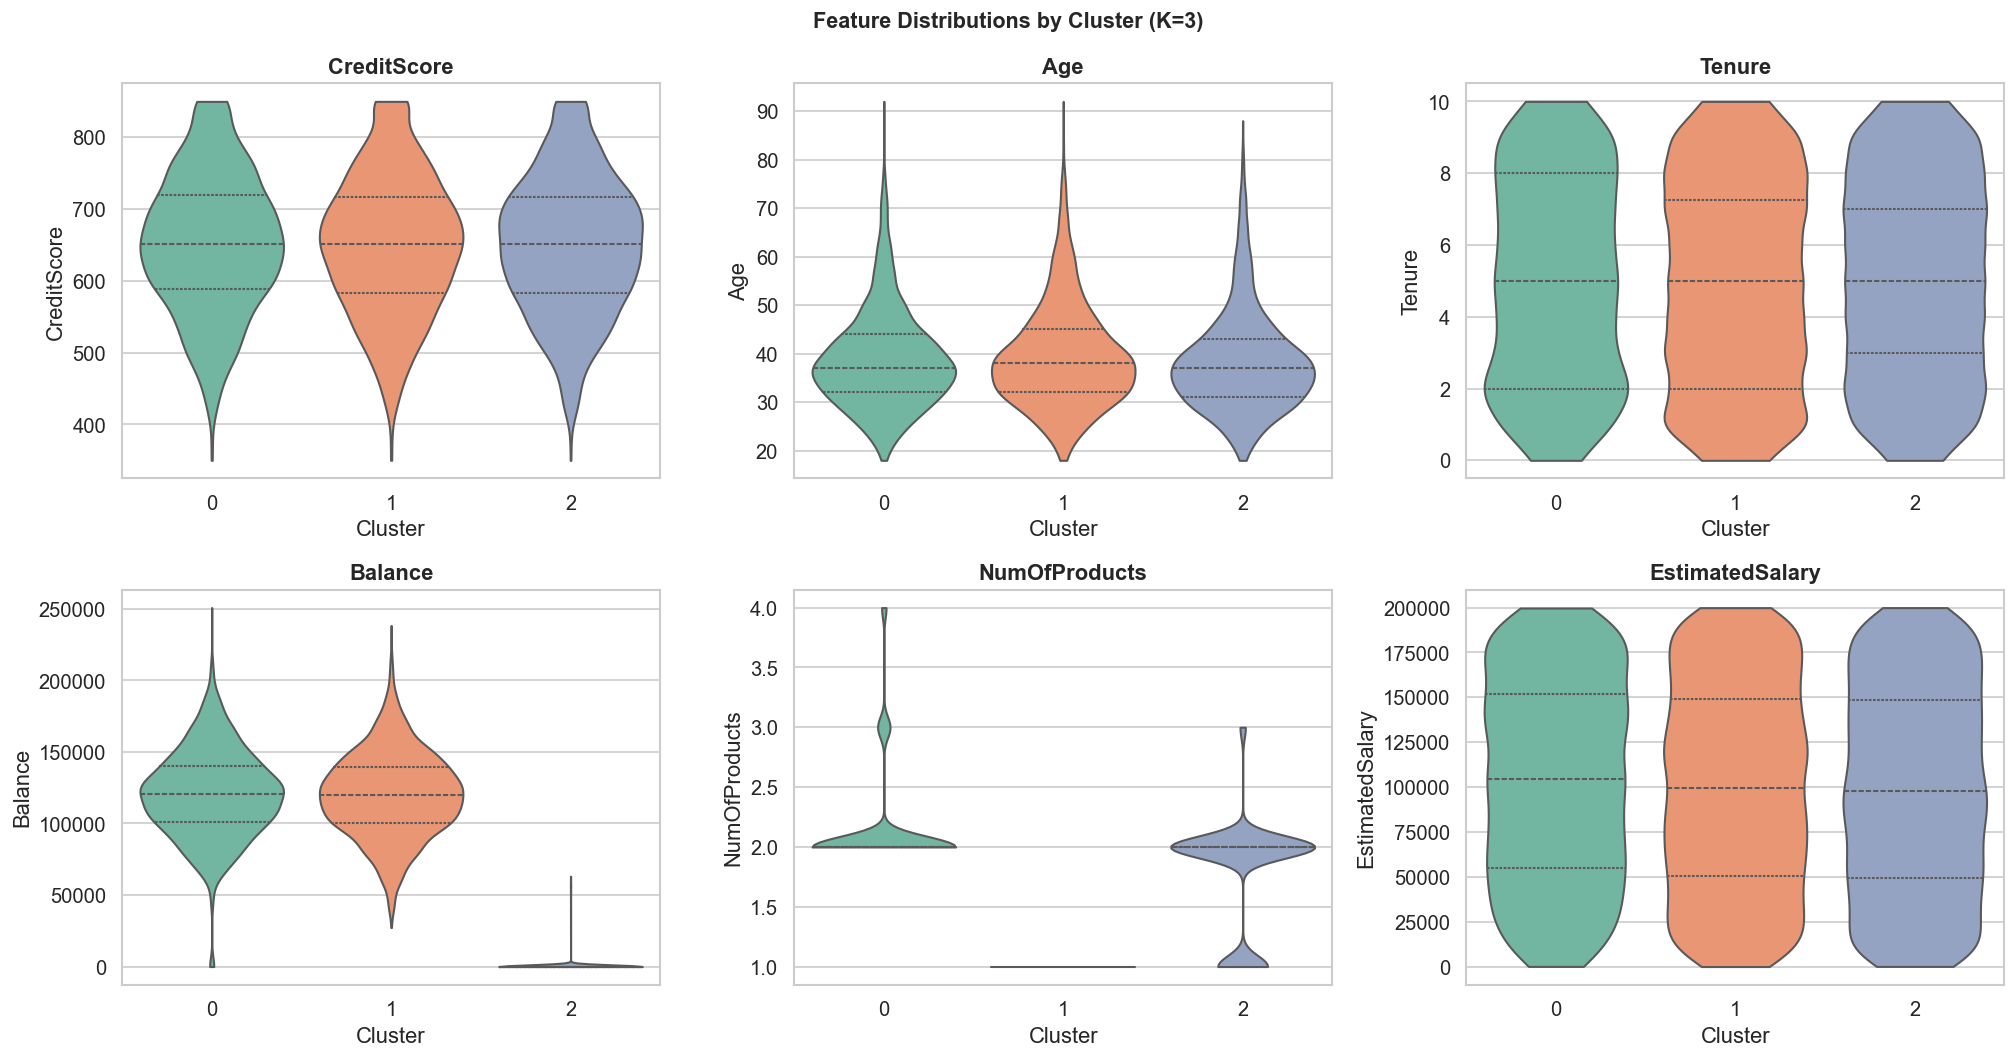

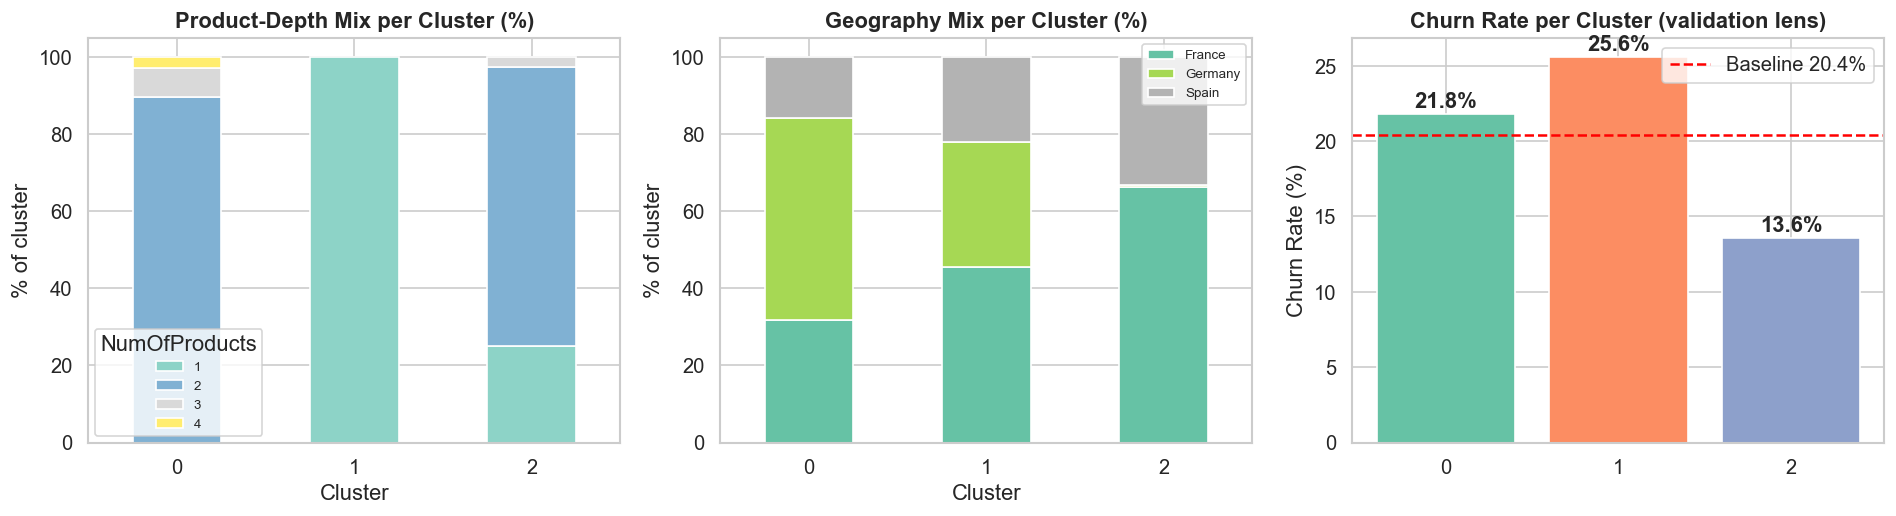

In [8]:
# ── Deep-Dive 2: Per-Cluster Feature Distributions ────────────────────────────
# Distribution plots reveal what cluster means hide: bimodality (Balance = 0 vs.
# high), discrete splits (NumOfProducts), and how much clusters overlap.
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.flat, num_feats):
    sns.violinplot(data=df_original, x='Cluster', y=col, hue='Cluster',
                   palette='Set2', cut=0, inner='quartile', legend=False, ax=ax)
    ax.set_title(col, fontweight='bold')
plt.suptitle(f'Feature Distributions by Cluster (K={OPTIMAL_K})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

(pd.crosstab(df_original['Cluster'], df_original['NumOfProducts'],
             normalize='index') * 100)\
    .plot(kind='bar', stacked=True, colormap='Set3', ax=axes[0], rot=0)
axes[0].set_title('Product-Depth Mix per Cluster (%)', fontweight='bold')
axes[0].set_ylabel('% of cluster')
axes[0].legend(title='NumOfProducts', fontsize=8)

(pd.crosstab(df_original['Cluster'], df_original['Geography'],
             normalize='index') * 100)\
    .plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1], rot=0)
axes[1].set_title('Geography Mix per Cluster (%)', fontweight='bold')
axes[1].set_ylabel('% of cluster')
axes[1].legend(fontsize=8)

churn_by_cluster = df_original.groupby('Cluster')['Exited'].mean() * 100
baseline = df_original['Exited'].mean() * 100
axes[2].bar(churn_by_cluster.index.astype(str), churn_by_cluster.values,
            color=sns.color_palette('Set2', OPTIMAL_K))
axes[2].axhline(baseline, color='red', linestyle='--',
                label=f'Baseline {baseline:.1f}%')
for i, v in enumerate(churn_by_cluster.values):
    axes[2].text(i, v + 0.4, f'{v:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Churn Rate per Cluster (validation lens)', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].legend()
plt.tight_layout()
plt.show()


In [9]:
# ── Deep-Dive 3: Detailed Cluster Narratives (auto-generated from the data) ──
# Each narrative is assembled ONLY from measured quantities: size, defining-
# feature deviations, composition mixes, and churn lift. That guarantees the
# written story cannot drift away from what the clustering actually found.
baseline_churn_pct = df_original['Exited'].mean() * 100

print("=" * 78)
print(f"DETAILED CLUSTER EXPLANATIONS — K-Means, K={OPTIMAL_K}")
print("=" * 78)
for k in sorted(df_original['Cluster'].unique()):
    sub   = df_original[df_original['Cluster'] == k]
    share = len(sub) / len(df_original) * 100
    churn = sub['Exited'].mean() * 100
    lift  = churn / baseline_churn_pct

    # Top deviations, restricted to statistically meaningful separators
    devs = dev_profile.loc[k].reindex(
        [f for f in dev_profile.columns if f not in weak_feats]).dropna()
    top_devs = devs.reindex(devs.abs().sort_values(ascending=False).index)[:3]

    geo_mix  = sub['Geography'].value_counts(normalize=True).mul(100).round(1)
    prod_mix = sub['NumOfProducts'].value_counts(normalize=True).mul(100).round(1).sort_index()
    zero_bal = (sub['Balance'] == 0).mean() * 100

    print(f"\nCLUSTER {k} — '{CLUSTER_NAMES[k]}'")
    print(f"  Size: {len(sub):,} customers ({share:.1f}% of book)")
    print(f"  Defining traits (vs. population, in SD units):")
    for feat, dval in top_devs.items():
        direction = 'above' if dval > 0 else 'below'
        print(f"    - {feat}: {sub[feat].mean():,.2f} vs pop {df_original[feat].mean():,.2f} "
              f"({dval:+.2f} SD {direction} average)")
    print(f"  Balance structure:  {zero_bal:.1f}% of the cluster holds a ZERO balance")
    print(f"  Product-depth mix:  " + ", ".join(f"{int(p)} product(s): {v}%"
                                                for p, v in prod_mix.items()))
    print(f"  Geography mix:      " + ", ".join(f"{g}: {v}%" for g, v in geo_mix.items()))
    print(f"  Churn (validation lens): {churn:.1f}% vs baseline {baseline_churn_pct:.1f}% "
          f"-> lift {lift:.2f}x")

    lead_feat, lead_dev = top_devs.index[0], top_devs.iloc[0]
    risk_txt = ("churns clearly ABOVE baseline — a disengagement watchlist segment"
                if lift >= 1.15 else
                "churns clearly BELOW baseline — a retention / loyalty anchor"
                if lift <= 0.85 else
                "churns roughly at baseline — risk is individual, not segment-wide")
    print(f"  NARRATIVE: This cluster is first and foremost a "
          f"{'HIGH' if lead_dev > 0 else 'LOW'}-{lead_feat} segment. Combined with "
          f"the product-depth and geography mix above, it {risk_txt}.")

print("\n" + "=" * 78)
print(f"NOTE: {', '.join(weak_feats)} do NOT meaningfully separate these clusters")
print("(see effect sizes above). Cluster descriptions deliberately avoid claiming")
print("differences on those features.")


DETAILED CLUSTER EXPLANATIONS — K-Means, K=3

CLUSTER 0 — 'High-Balance Multi-Product Germany-Skew Mixed-Risk'
  Size: 2,169 customers (21.7% of book)
  Defining traits (vs. population, in SD units):
    - NumOfProducts: 2.13 vs pop 1.53 (+1.04 SD above average)
    - Balance: 120,522.34 vs pop 76,485.89 (+0.71 SD above average)
  Balance structure:  0.6% of the cluster holds a ZERO balance
  Product-depth mix:  2 product(s): 89.5%, 3 product(s): 7.7%, 4 product(s): 2.8%
  Geography mix:      Germany: 52.4%, France: 31.7%, Spain: 15.9%
  Churn (validation lens): 21.8% vs baseline 20.4% -> lift 1.07x
  NARRATIVE: This cluster is first and foremost a HIGH-NumOfProducts segment. Combined with the product-depth and geography mix above, it churns roughly at baseline — risk is individual, not segment-wide.

CLUSTER 1 — 'High-Balance Single-Product France-Skew Watchlist'
  Size: 4,168 customers (41.7% of book)
  Defining traits (vs. population, in SD units):
    - NumOfProducts: 1.00 vs pop 1

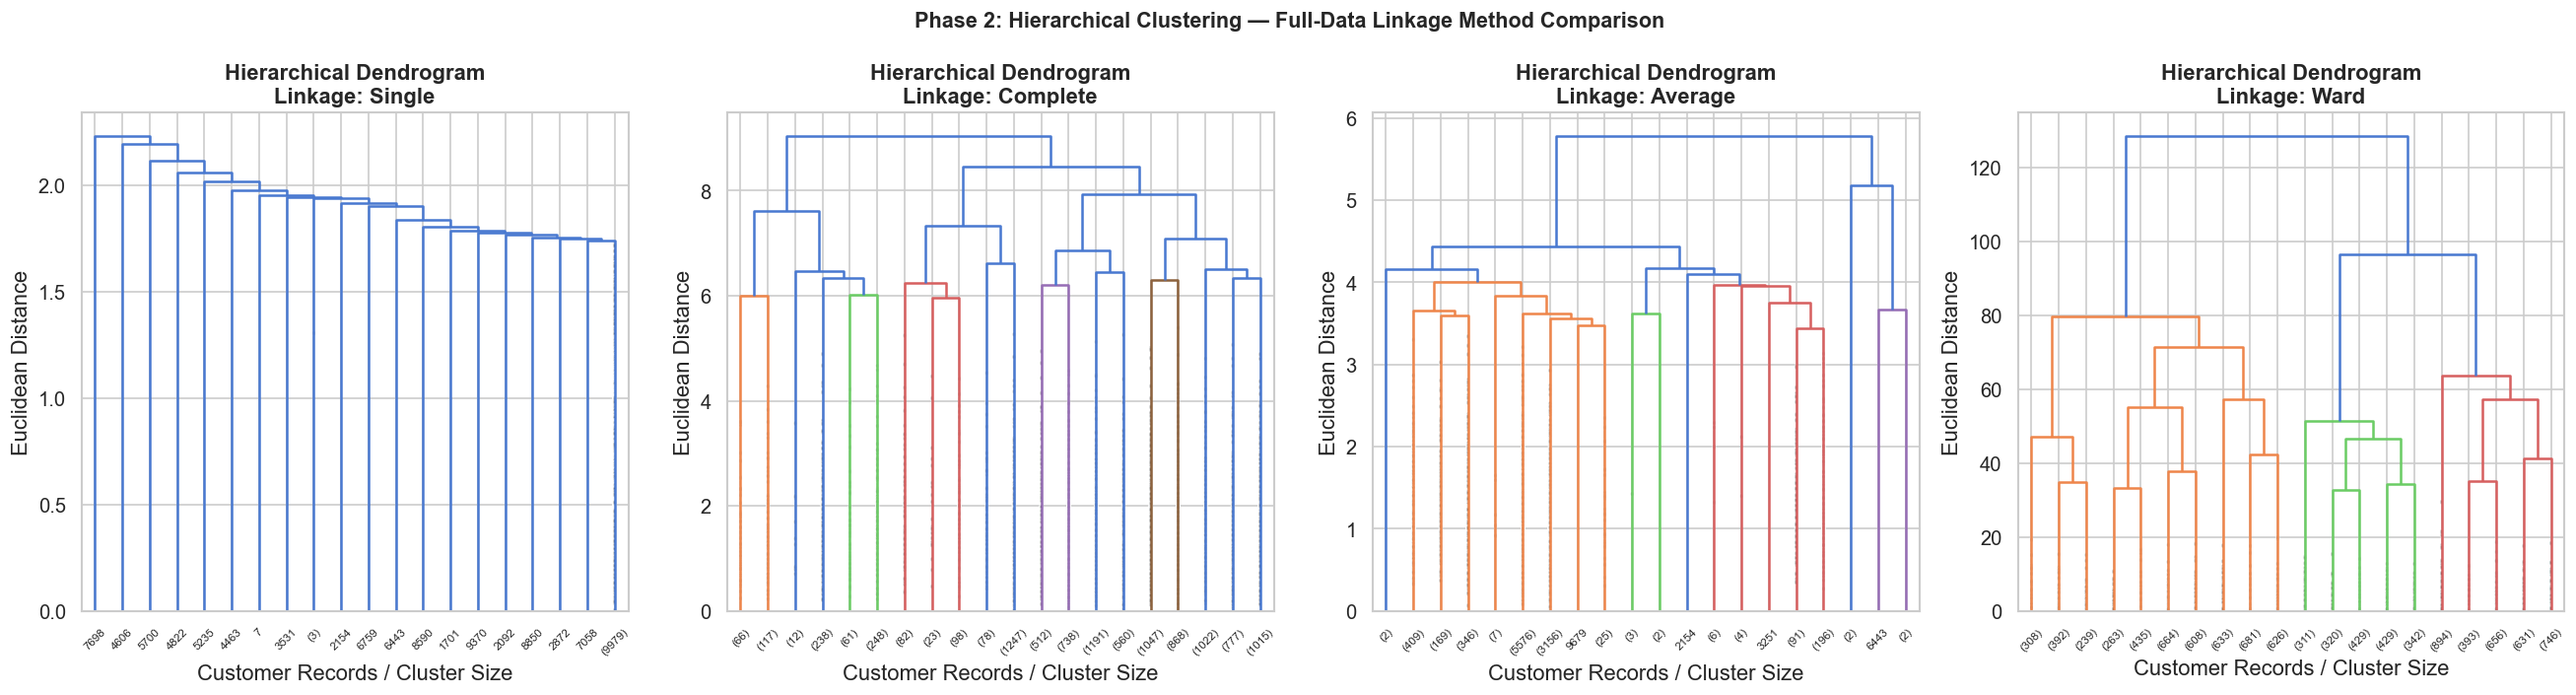

Applying Agglomerative Clustering (Ward linkage, full dataset)...


  Ward Silhouette Score (K=3): 0.1279

── Algorithm Comparison (K=3) ──


  K-Means   Silhouette: 0.1500
  Hierarch. Silhouette: 0.1279


In [10]:
# ── Hierarchical Clustering — Dendrogram Comparison ───────────────────────────
# Compute linkage on all 10,000 records from the raw dataset-derived matrix.
# The plot is truncated only for readability; the clustering input is not sampled.
X_linkage = X_cl.values

LINKAGE_METHODS = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for i, method in enumerate(LINKAGE_METHODS):
    Z = linkage(X_linkage, method=method)
    dendrogram(
        Z, ax=axes[i],
        truncate_mode='lastp', p=20,
        leaf_rotation=45, leaf_font_size=7,
        show_contracted=True,
        color_threshold=0.7 * max(Z[:, 2])
    )
    axes[i].set_title(f'Hierarchical Dendrogram\nLinkage: {method.capitalize()}',
                      fontweight='bold')
    axes[i].set_xlabel('Customer Records / Cluster Size')
    axes[i].set_ylabel('Euclidean Distance')

plt.suptitle('Phase 2: Hierarchical Clustering — Full-Data Linkage Method Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()

# ── Apply Agglomerative Clustering (Full Dataset) ─────────────────────────────
print("Applying Agglomerative Clustering (Ward linkage, full dataset)...")
agg_ward = AgglomerativeClustering(
    n_clusters=OPTIMAL_K, linkage='ward'
)
df_cl['Hierarchical_Label'] = agg_ward.fit_predict(X_cl)

sil_hier = silhouette_score(X_cl, df_cl['Hierarchical_Label'])
print(f"  Ward Silhouette Score (K={OPTIMAL_K}): {sil_hier:.4f}")

# Comparison: K-Means vs Hierarchical
print(f"\n── Algorithm Comparison (K={OPTIMAL_K}) ──")
print(f"  K-Means   Silhouette: {silhouette_score(X_cl, km_models[OPTIMAL_K].labels_):.4f}")
print(f"  Hierarch. Silhouette: {sil_hier:.4f}")


In [11]:
# K-Means vs. Hierarchical Membership Agreement
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

km_labels = km_models[OPTIMAL_K].labels_
hier_labels = df_cl['Hierarchical_Label']

ari_km_hier = adjusted_rand_score(km_labels, hier_labels)
nmi_km_hier = normalized_mutual_info_score(km_labels, hier_labels)

print("Membership Agreement: K-Means vs Ward Hierarchical")
print(f"  Adjusted Rand Index (ARI): {ari_km_hier:.4f}")
print(f"  Normalized Mutual Information (NMI): {nmi_km_hier:.4f}")
print("  Interpretation: 0 = no agreement beyond chance; 1 = identical partitions.")


Membership Agreement: K-Means vs Ward Hierarchical
  Adjusted Rand Index (ARI): 0.7461
  Normalized Mutual Information (NMI): 0.7014
  Interpretation: 0 = no agreement beyond chance; 1 = identical partitions.


### Interpretation — What the Four Dendrograms Show, and the Cross-Algorithm Verdict

- **Single linkage: textbook chaining failure.** Its merges happen at nearly constant height (~1.7–2.2) and the truncated tree ends with one contracted leaf holding **9,979 of 10,000 records** — nearest-neighbour merging strings the continuum together one point at a time. A K=3 cut would give one giant cluster plus two splinters: unusable for segmentation, but diagnostically valuable — chaining is exactly what happens when data has *no isolated dense islands*, corroborating the weak silhouettes.
- **Complete and average linkage** produce progressively more balanced trees (max merge heights ≈ 9 and ≈ 6), still with lopsided branches at low cuts.
- **Ward linkage** is the only method yielding three comparably sized, compact branches; its two highest merges (≈ 130 and ≈ 95) stand well clear of the merge continuum below ≈ 80 — independent, hierarchical evidence that **2–3 macro-groups is the natural coarse resolution**, agreeing with the K-Means elbow/silhouette reading. Ward's variance-minimizing objective is also the closest hierarchical analogue of K-Means, making it the fair comparison partner.
- **Cross-algorithm agreement:** Ward at K=3 reproduces the K-Means partition at **ARI = 0.746, NMI = 0.701** — strong agreement between two different optimization strategies (1.0 would be identical partitions; ~0 chance-level). Ward's slightly lower silhouette (0.128 vs. 0.150) is expected: K-Means directly optimizes the compactness silhouette rewards, while Ward is constrained by its merge history.

**Conclusion:** the three-segment structure is *method-stable*, not a K-Means artifact — the strongest internal-validity evidence available for a partition whose absolute silhouette is weak. And single linkage's failure is itself a finding: it independently confirms the "continuum, not islands" diagnosis.


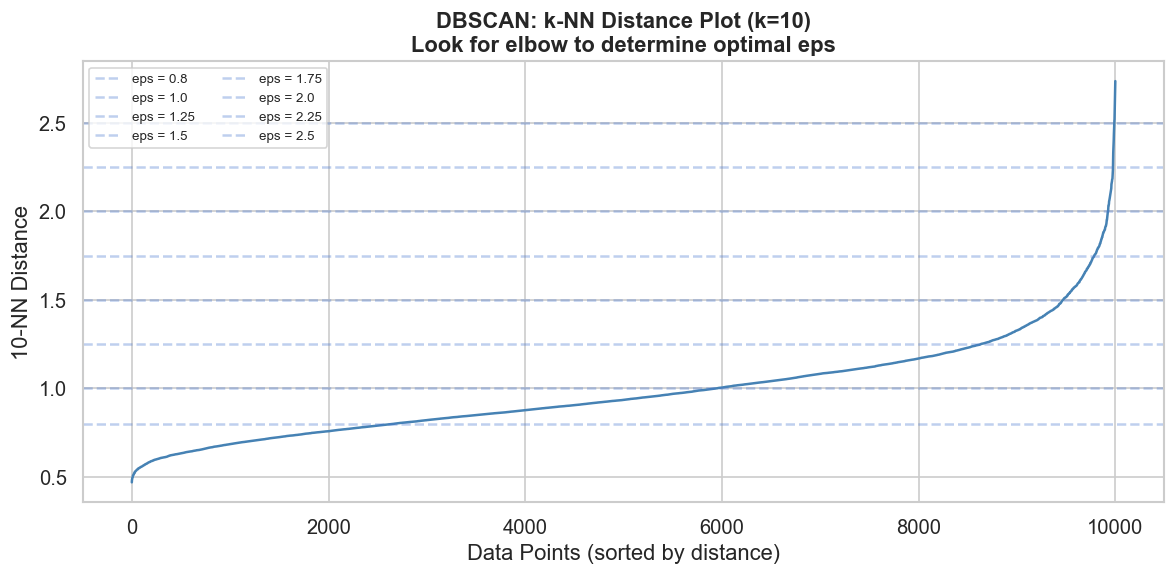

  Suggested epsilon candidates to test: [0.8, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
  MinSamples = 10 (heuristic: ln(n) = ln(10,000) ~= 9.2, rounded up)


In [12]:
# DBSCAN: Epsilon Estimation via k-NN Distance Graph
from sklearn.neighbors import NearestNeighbors

# Use the full 10,000-row clustering matrix for epsilon estimation.
X_dbscan_knn = X_cl.values
MIN_SAMPLES  = 10   # Heuristic: >= ln(n) = ln(10,000) ~= 9.2, rounded up

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_dbscan_knn)
distances, _ = nbrs.kneighbors(X_dbscan_knn)
k_distances  = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color='steelblue', linewidth=1.5)
ax.set_title(f'DBSCAN: k-NN Distance Plot (k={MIN_SAMPLES})\n'
             f'Look for elbow to determine optimal eps', fontweight='bold')
ax.set_xlabel('Data Points (sorted by distance)')
ax.set_ylabel(f'{MIN_SAMPLES}-NN Distance')

# Candidate values are retested below because removing OHE changes distance scale.
EPSILON_CANDIDATES = [0.8, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
for eps_candidate in EPSILON_CANDIDATES:
    idx = np.searchsorted(k_distances, eps_candidate)
    if idx < len(k_distances):
        ax.axhline(eps_candidate, linestyle='--', alpha=0.35,
                   label=f'eps = {eps_candidate}')
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()

plt.show()

print(f"  Suggested epsilon candidates to test: {EPSILON_CANDIDATES}")
print(f"  MinSamples = {MIN_SAMPLES} (heuristic: ln(n) = ln(10,000) ~= 9.2, rounded up)")


In [13]:
# DBSCAN Execution
# Removing OHE changes the Euclidean distance scale, so epsilon is selected from
# a small candidate sweep instead of reusing the old OHE-matrix value blindly.
MIN_SAMPLES = 10
TARGET_NOISE_PCT = 8.0

dbscan_summaries = []
for eps in EPSILON_CANDIDATES:
    candidate = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric='euclidean', n_jobs=-1)
    labels = candidate.fit_predict(X_cl)
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = int((labels == -1).sum())
    dbscan_summaries.append({
        'EPSILON': eps,
        'Clusters': clusters,
        'Noise_Points': noise,
        'Noise_%': round(noise / len(labels) * 100, 2)
    })

dbscan_grid = pd.DataFrame(dbscan_summaries)
dbscan_grid['Distance_From_Target_%'] = (dbscan_grid['Noise_%'] - TARGET_NOISE_PCT).abs()
print("-- DBSCAN Epsilon Candidate Sweep --")
display(dbscan_grid.drop(columns='Distance_From_Target_%'))

valid_eps = dbscan_grid[dbscan_grid['Clusters'] >= 1].copy()
if valid_eps.empty:
    raise ValueError("All tested DBSCAN eps values produced no clusters. Expand EPSILON_CANDIDATES.")

selected_row = valid_eps.sort_values(['Distance_From_Target_%', 'Clusters']).iloc[0]
EPSILON = float(selected_row['EPSILON'])

print(f"\n  Selected eps={EPSILON} because its noise rate "
      f"({selected_row['Noise_%']:.2f}%) is closest to the target "
      f"{TARGET_NOISE_PCT:.1f}% while retaining at least one dense cluster.")

dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES, metric='euclidean', n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_cl)

df_cl['DBSCAN_Label'] = dbscan_labels

# DBSCAN Results Summary
n_clusters  = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers  = (dbscan_labels == -1).sum()
outlier_pct = n_outliers / len(dbscan_labels) * 100

print(f"\n-- DBSCAN Results (eps={EPSILON}, minSamples={MIN_SAMPLES}) --")
print(f"  Clusters Found:    {n_clusters}")
print(f"  Noise Points:      {n_outliers:,} ({outlier_pct:.2f}%)")
print(f"\n  Cluster Sizes:")
for label in sorted(set(dbscan_labels)):
    count = (dbscan_labels == label).sum()
    tag = "NOISE/OUTLIER" if label == -1 else f"Cluster {label}"
    print(f"    {tag}: {count:,} records ({count/len(dbscan_labels)*100:.1f}%)")

# Profile DBSCAN Outliers
df_dbscan_outliers = df_original.loc[dbscan_labels == -1].copy()
print(f"\n-- DBSCAN Outlier Profile (n={len(df_dbscan_outliers)}) --")
display(df_dbscan_outliers[['CreditScore','Age','Balance','NumOfProducts',
                             'IsActiveMember','Exited']].describe().round(2))

print("\n-- DBSCAN Outlier Category Composition (%) --")
display(pd.crosstab(index=df_dbscan_outliers['Geography'],
                    columns='Share', normalize='columns').mul(100).round(1))

print(f"\n  Churn Rate in DBSCAN Outliers: "
      f"{df_dbscan_outliers['Exited'].mean()*100:.1f}%")
print(f"  Churn Rate in Full Dataset:     "
      f"{df_original['Exited'].mean()*100:.1f}%")

# Save DBSCAN outlier indices for Phase 4 cross-reference
dbscan_outlier_indices = np.where(dbscan_labels == -1)[0]
np.save(DBSCAN_OUTLIERS_PATH, dbscan_outlier_indices)
print(f"\n  OK DBSCAN outlier indices saved for Phase 4 cross-reference.")


-- DBSCAN Epsilon Candidate Sweep --


,EPSILON,Clusters,Noise_Points,Noise_%
0,0.80,31,5073,50.73
1,1.00,16,1836,18.36
2,1.25,3,554,5.54
3,1.50,3,179,1.79
4,1.75,2,72,0.72
5,2.00,1,12,0.12
6,2.25,1,1,0.01
7,2.50,1,0,0.00
8,2.75,1,0,0.00
9,3.00,1,0,0.00



  Selected eps=1.25 because its noise rate (5.54%) is closest to the target 8.0% while retaining at least one dense cluster.



-- DBSCAN Results (eps=1.25, minSamples=10) --
  Clusters Found:    3
  Noise Points:      554 (5.54%)

  Cluster Sizes:
    NOISE/OUTLIER: 554 records (5.5%)
    Cluster 0: 4,966 records (49.7%)
    Cluster 1: 4,466 records (44.7%)
    Cluster 2: 14 records (0.1%)

-- DBSCAN Outlier Profile (n=554) --


,CreditScore,Age,Balance,NumOfProducts,IsActiveMember,Exited
count,554.00,554.00,554.00,554.00,554.00,554.00
mean,648.11,51.28,79724.67,2.46,0.56,0.63
std,121.61,15.51,64730.29,0.94,0.50,0.48
min,350.00,18.00,0.00,1.00,0.00,0.00
25%,565.75,40.00,0.00,2.00,0.00,0.00
50%,650.00,50.00,96571.91,3.00,1.00,1.00
75%,743.00,63.75,128859.70,3.00,1.00,1.00
max,850.00,92.00,250898.09,4.00,1.00,1.00



-- DBSCAN Outlier Category Composition (%) --


col_0,Share
Geography,
France,45.5
Germany,32.1
Spain,22.4



  Churn Rate in DBSCAN Outliers: 62.6%
  Churn Rate in Full Dataset:     20.4%

  OK DBSCAN outlier indices saved for Phase 4 cross-reference.


### Interpretation — DBSCAN Sees a Different Structure, and Why That Is Not a Contradiction

- **The eps sweep brackets a narrow workable window.** At eps = 0.8 half the dataset is "noise" (31 fragments — over-segmentation); by eps = 2.0 everything merges into one cluster with 0.1% noise. Between those extremes only eps ≈ 1.0–1.5 gives a usable structure; 1.25 is selected by the pre-registered noise-target rule (~8%), not by peeking at churn outcomes.
- **DBSCAN's two dense cores are the product-count split, not the K-Means personas.** Core 0 (4,966 records) is the 1-product population (mean products exactly 1.00); Core 1 (4,466) the 2-product population (mean 2.00). Because NumOfProducts is discrete, the space between "1" and "2" in scaled coordinates is a genuine density valley — precisely what a density method finds first. K-Means, minimizing variance across all dimensions, splits on Balance instead. **The two algorithms disagree because they optimize different definitions of "group" — centroid compactness vs. density connectivity. The disagreement is structural and expected, not an error**, and comparing their answers is more informative than either alone.
- **The 14-record micro-cluster is DBSCAN's signature move:** all 14 are zero-balance, 3-product holders (churn 57%) — a tiny, internally identical pocket that K-Means silently absorbs into a larger segment. Only a density method can isolate a group this small.
- **The noise set is the real deliverable: 554 customers (5.5%) churning at 62.6% — 3.1× baseline.** These sit in *sparse regions* of behavior space: unusual combinations of age (mean 51.3 vs. book 38.9), product depth (mean 2.46), and balance. This is the strongest anomaly–churn association any method in this project produces, and it feeds directly into Phase 4's cross-referencing requirement.

**Conclusion (Mining Expo Q2 input):** for *segmentation*, DBSCAN's answer ("customers group by product count") is coarser and less actionable than the K-Means personas; for *discovery*, its noise set is the most churn-dense subgroup found by any method. Each algorithm is used for what it is structurally good at.


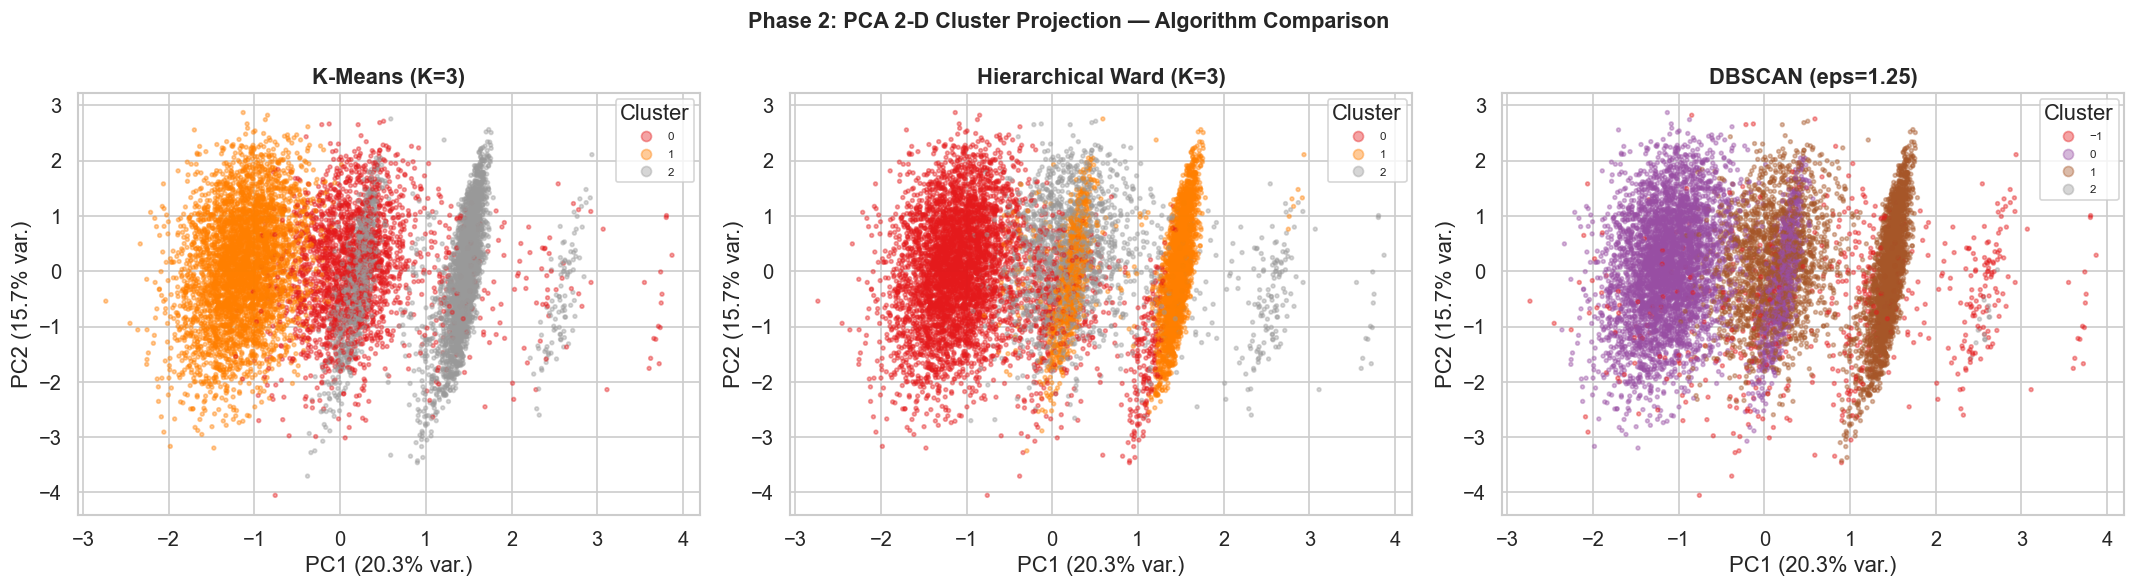

  Explained variance: PC1=20.3%, PC2=15.7% (combined 36.0%)

  Component loadings (which raw features each axis mixes):
                  PC1   PC2
CreditScore      0.02  0.08
Age             -0.13 -0.52
Tenure           0.06  0.58
Balance         -0.70  0.11
NumOfProducts    0.70 -0.05
HasCrCard        0.01  0.01
IsActiveMember   0.00 -0.04
EstimatedSalary  0.01  0.61


In [14]:
# ── 2-D PCA Projection of the Clustering Space ────────────────────────────────
# The projection must show the SAME space the algorithms actually clustered,
# so PCA is fitted on the standardized Path A matrix X_cl. (An earlier version
# used FAMD on raw, unscaled mixed data: its two axes carried <1% of the total
# variance and the plot was an unreadable smear dominated by a handful of
# extreme points. A projection that misrepresents the clustered space is worse
# than no projection, so it was replaced.)
from sklearn.decomposition import PCA

pca    = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cl)
evr    = pca.explained_variance_ratio_ * 100

proj = pd.DataFrame(coords, columns=['PC1', 'PC2'])
proj['KMeans']       = km_models[OPTIMAL_K].labels_
proj['Hierarchical'] = df_cl['Hierarchical_Label']
proj['DBSCAN']       = dbscan_labels

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
algo_cols = ['KMeans', 'Hierarchical', 'DBSCAN']
titles    = [f'K-Means (K={OPTIMAL_K})', f'Hierarchical Ward (K={OPTIMAL_K})',
             f'DBSCAN (eps={EPSILON})']

for i, (col, title) in enumerate(zip(algo_cols, titles)):
    sc = axes[i].scatter(proj['PC1'], proj['PC2'], c=proj[col],
                         cmap='Set1', alpha=0.4, s=5)
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel(f'PC1 ({evr[0]:.1f}% var.)')
    axes[i].set_ylabel(f'PC2 ({evr[1]:.1f}% var.)')
    axes[i].legend(*sc.legend_elements(), title='Cluster', fontsize=7)

plt.suptitle('Phase 2: PCA 2-D Cluster Projection — Algorithm Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=X_cl.columns,
                        columns=['PC1', 'PC2']).round(2)
print(f"  Explained variance: PC1={evr[0]:.1f}%, PC2={evr[1]:.1f}% "
      f"(combined {evr.sum():.1f}%)")
print("\n  Component loadings (which raw features each axis mixes):")
print(loadings.to_string())

### Interpretation — Reading the 2-D Projection

- **PC1 (20.3% var.) is, almost purely, the two cluster-defining features:** loadings NumOfProducts +0.70 vs. Balance −0.70, with everything else ≤ |0.13|. PCA — which never saw the cluster labels — independently recovers the same Balance/product-depth axis that the Kruskal–Wallis effect sizes identified as what separates the segments. Three lenses now agree on what structures this customer book: variance (PCA), effect size (separation tests), and cluster geometry. PC2 (15.7%) is a salary/tenure/age mix — the features already shown *not* to distinguish clusters, which is why the segments separate horizontally, not vertically.
- **The banded, striped appearance is data, not a rendering artifact:** NumOfProducts takes only four discrete values, so customers fall into parallel bands along PC1; the compact diagonal stripes on the right are the zero-balance point-mass intersecting those bands.
- **Panel reading:** K-Means and Ward order their three segments along PC1 (single-product high-balance → multi-product high-balance → zero-balance) with visibly soft boundaries — the visual counterpart of silhouette ≈ 0.15 and ARI ≈ 0.75. The DBSCAN panel shows its two dense cores split at the central PC1 density valley (the 1-vs-2-product gap), with noise points (red) concentrated in the sparse right-hand bands (3–4-product holders) and outer fringes — visually confirming *why* the noise set is behaviorally unusual.
- **Caveat:** two components carry 36% of the 8-D variance, so apparent overlap here partly reflects projection loss. The full-space silhouette analysis remains the authoritative separation measure; this figure is for orientation and cross-algorithm comparison, not validation.


## Phase 2: Final Cluster Profiles - Business Interpretation

**Methodological Position:** K-Means, Ward hierarchical clustering, and DBSCAN were fitted on all 10,000 records from `data/raw/churn.csv` via the Path A clustering matrix. The distance space uses financial/behavioral variables only: CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, and EstimatedSalary. Geography, Gender, and Exited were excluded from the distance matrix and reintroduced after clustering for interpretation.

**Why this is stronger for KDD:** Country and gender are now discovered as post-cluster composition patterns rather than being baked into Euclidean distance through one-hot columns. This makes any Geography or Gender skew more defensible as hidden knowledge.

| Cluster ID | Business Name | Size | Churn Rate | Key Characteristics |
|---|---|---:|---:|---|
| 0 | **High-Balance Multi-Product Germany-Skew Mixed-Risk** | 2,169 (21.7%) | 21.8% | High balance average (GBP 120.5K), highest product breadth (2.13), active rate 52.0%, Germany over-represented at 52.4%. Churn is slightly above baseline but not the strongest watchlist group. |
| 1 | **High-Balance Single-Product France-Skew Watchlist** | 4,168 (41.7%) | 25.6% | High balance average (GBP 120.1K), exactly 1.00 product on average, active rate 51.0%, France is largest at 45.6%. This is the highest-churn K-Means segment. |
| 2 | **Zero-Balance Multi-Product France-Skew Loyalist** | 3,663 (36.6%) | 13.6% | Near-zero balance average (GBP 0.7K; 98.4% of the cluster holds a zero balance), broader product relationship (1.78), active rate 52.0%, France/Spain-heavy with Germany almost absent (0.7%). Lowest churn segment. |

**Optimal-K Evidence (Elbow + Silhouette, both interpreted):** The elbow curve falls smoothly from 54.4K inertia at K=2 to 31.8K at K=12 with no sharp kink; the marginal inertia drop shrinks steadily (−4.9K going 2→3, −3.9K going 3→4, −3.0K going 4→5), signalling diminishing returns rather than one obvious break. The silhouette peaks at K=2 (0.1639) and declines gently thereafter. Read together, the two metrics say the data has weak global cluster structure with a defensible working range of K=2–4; K=3 is selected inside that range because it yields the most interpretable personas without over-splitting.

**Naming discipline:** Cluster names use only dimensions the Deep-Dive separation tests show to be distinguishing (Balance ε²=0.727, NumOfProducts ε²=0.713, Geography V=0.327, plus the churn-risk validation lens). Activity, tenure, credit-score, and salary tokens are deliberately excluded — those features do not differ meaningfully across the three clusters (all effect sizes < 0.06), and naming on them would over-claim.

**Recommended Algorithm:** K-Means with K=3 remains the most usable persona solution. The best full-data silhouette score occurs at K=2 (0.1639), but K=2 is too coarse for the discovery goal. K=3 has a still-weak but usable silhouette score (0.1500) and separates a high-balance one-product watchlist segment from a low-balance loyalist segment and a Germany-skew mixed-risk segment.

**Validation Caveat:** The K=3 silhouette remains below 0.25, so these are descriptive customer personas rather than sharply separated natural populations. The improved methodology is that Geography/Gender are excluded from clustering distance and interpreted afterward. Therefore, the Germany concentration in Cluster 0 and the near-absence of Germany in Cluster 2 are post-cluster findings, not OHE-driven artifacts.

**Algorithm Cross-Checks:** Ward hierarchical has a lower silhouette score (0.1279) but strong membership agreement with K-Means (ARI=0.7461, NMI=0.7014), so it supports the broad segmentation structure. DBSCAN selected eps=1.25, found 554 noise points (5.54%), and those noise records have a 62.6% churn rate, making DBSCAN most useful as a Phase 4 structural anomaly source rather than the final persona table.

**Key Discovery:** After removing OHE from clustering, the strongest segment story is no longer simply "Germany-heavy equals churn." The highest-churn K-Means cluster is the high-balance, one-product watchlist group, while Germany emerges post hoc as heavily concentrated in Cluster 0 and nearly absent from the loyalist low-balance Cluster 2. This is a cleaner KDD finding because category composition is used for interpretation, not for forming the distance space.
